In [ ]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import polars as pl
# %pip install polars
import sys
import psutil
import platform
import gc
from tqdm import tqdm
import pyarrow as pa
import pyarrow.parquet as pq


# csv_path=r"C:\Users\Administrator\Desktop\Chess\data\processed\hpc_results\HPC_RESULTS.csv"
# csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\temp2.8.csv"
# df=pd.read_csv(csv_path)

In [31]:
df.columns

Index(['row_idx', 'UID', 'White', 'Black', 'White CP Loss', 'White Accuracy',
       'Black CP Loss', 'Black Accuracy', 'Stage Analysis', 'Evaluation',
       'ComplexityE', 'Judgments', 'White Blunders', 'White Mistakes',
       'White Inaccuracies', 'Black Blunders', 'Black Mistakes',
       'Black Inaccuracies', 'Complexity E1', 'Complexity E2', 'Complexity E3',
       'Complexity E4', 'Complexity E5', 'Complexity P', 'Complexity S',
       'White Complexity Sum', 'Black Complexity Sum'],
      dtype='object')

In [32]:
df=df.drop(columns=['row_idx', 'White CP Loss', 'White Accuracy','Black CP Loss', 'Black Accuracy', 'Stage Analysis', 'Evaluation',
                    'White Blunders', 'White Mistakes','White Inaccuracies', 'Black Blunders', 'Black Mistakes','Black Inaccuracies',
                    'Complexity P', 'Complexity S','White Complexity Sum', 'Black Complexity Sum'])
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r'\s+', '_', regex=True)
)
df.columns

Index(['UID', 'White', 'Black', 'ComplexityE', 'Judgments', 'Complexity_E1',
       'Complexity_E2', 'Complexity_E3', 'Complexity_E4', 'Complexity_E5'],
      dtype='object')

In [33]:
df.head()

,UID,White,Black,ComplexityE,Judgments,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,"33,36,30,44,32,39,40,39,32,50,42,66,56,70,58,8...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inaccu...","36,33,36,30,44,32,39,40,39,32,50,42,66,56,70,5...","34,34,33,63,35,37,38,47,23,46,40,55,58,57,55,6...","31,34,27,66,26,67,36,60,17,49,29,55,48,65,29,7...","25,42,25,78,21,71,34,67,12,52,26,57,35,74,28,8...","16,48,20,79,21,72,25,83,11,53,18,62,28,90,27,9..."
1,35,AradNazari,Andre Bold,"28,37,39,36,18,14,36,42,40,35,37,41,35,35,34,3...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...","31,28,37,39,36,18,14,36,42,40,35,37,41,35,35,3...","30,30,33,40,35,93,-22,36,2,41,19,76,29,262,-46...","28,31,27,41,32,141,-55,39,-12,42,1,80,20,276,-...","23,31,27,43,28,141,-67,47,-22,52,-13,92,5,345,...","12,50,26,45,16,180,-85,48,-51,52,-19,119,-3,38..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,"29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,27,1...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inac...","25,29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,2...","21,31,44,44,29,29,10,9,16,17,0,5,11,13,7,13,19...","20,31,40,55,14,36,8,12,3,17,-4,11,11,14,3,14,1...","13,32,33,60,9,41,8,23,0,19,-7,12,8,19,3,16,16,...","10,54,22,64,9,46,8,29,0,21,-18,17,8,22,3,18,10..."
3,37,Bartosz Przybylski,Joseph Ryan,"22,39,36,51,42,48,37,44,28,26,37,66,66,64,71,5...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...","29,22,39,36,51,42,48,37,44,28,26,37,66,66,64,7...","25,23,33,37,43,53,26,37,39,28,21,58,-8,66,49,9...","21,27,21,41,33,59,22,38,26,29,0,60,-23,69,49,1...","13,28,19,47,32,67,15,38,0,31,-22,80,-41,104,47...","7,48,10,51,25,68,1,39,-7,35,-25,87,-57,111,40,..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,"31,28,28,36,30,39,39,39,31,35,31,30,15,27,20,2...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...","35,31,28,28,36,30,39,39,39,31,35,31,30,15,27,2...","32,32,27,30,29,33,26,210,35,33,20,32,25,114,23...","20,32,15,35,25,35,23,212,30,36,17,35,23,398,22...","17,33,12,50,22,39,16,215,23,37,16,35,16,519,15...","17,43,6,60,16,40,15,229,22,43,13,37,12,521,13,..."


In [ ]:
# 高效版本 test1
MISSING = '__MISSING__'

def parse_chess_data(df):
    # 将不需要特殊 marker 处理的 Judgments 分开，避免在循环内做 if 判断
    complexity_cols = [
        'ComplexityE', 'Complexity_E1', 'Complexity_E2',
        'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
    ]

    # 1复杂度列：使用列表推导式替代 apply
    # 内联原先的 split_with_missing_marker 逻辑，省去数百万次函数调用开销
    for col in complexity_cols:
        if col in df.columns:
            df[col] = [
                [t if t.strip() != '' else MISSING for t in x.split(',')] if isinstance(x, str) else x
                for x in df[col]
            ]

    # 2Judgments 用原生列表推导式提速
    if 'Judgments' in df.columns:
        df['Judgments'] = [
            x.split(',') if isinstance(x, str) else x
            for x in df['Judgments']
        ]

    return df

df = parse_chess_data(df)
# df.head()

统计df里的missing有多少，确保前面真的填充上了

In [35]:
complexity_cols = [
    'ComplexityE', 'Complexity_E1', 'Complexity_E2',
    'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
]

total_missing = 0

for col in complexity_cols:
    total_missing += df[col].apply(
        lambda x: x.count(MISSING) if isinstance(x, list) else 0
    ).sum()

total_missing

np.int64(6906318)

In [36]:
df.shape

(712321, 10)

In [37]:
missing_by_col = {}

for col in df.columns:
    missing_by_col[col] = df[col].apply(
        lambda x: sum(1 for i in x if i == '__MISSING__') if isinstance(x, list) else 0
    ).sum()

missing_by_col

{'UID': np.int64(0),
 'White': np.int64(0),
 'Black': np.int64(0),
 'ComplexityE': np.int64(0),
 'Judgments': np.int64(0),
 'Complexity_E1': np.int64(0),
 'Complexity_E2': np.int64(462336),
 'Complexity_E3': np.int64(1236948),
 'Complexity_E4': np.int64(2151767),
 'Complexity_E5': np.int64(3055267)}

In [38]:
df.to_parquet('df1.parquet')

In [43]:
df.dtypes

UID               int64
White            object
Black            object
ComplexityE      object
Judgments        object
Complexity_E1    object
Complexity_E2    object
Complexity_E3    object
Complexity_E4    object
Complexity_E5    object
dtype: object

In [ ]:
# 减少df内存

# 使用 sys.intern 确保标记本身在内存中只有一份
MISSING = sys.intern('__MISSING__')

def parse_and_optimize_chess_data(df):
    # 棋手名字转为 category 极大地节省内存
    if 'White' in df.columns:
        df['White'] = df['White'].astype('category')
    if 'Black' in df.columns:
        df['Black'] = df['Black'].astype('category')
        
    # ID降级到 int32 或 uint32
    if 'UID' in df.columns:
        df['UID'] = pd.to_numeric(df['UID'], downcast='unsigned') # 如果 UID 没有负数，用 unsigned 最省

    # 列表解析与字符串内存共享
    complexity_cols = ['ComplexityE', 'Complexity_E1', 'Complexity_E2','Complexity_E3', 'Complexity_E4', 'Complexity_E5']

    # sys.intern() 包裹分割出的字符串
    for col in complexity_cols:
        if col in df.columns:
            df[col] = [
                # 让相同的数字字符串（如 '12'）在数据集中共享同一块内存
                [sys.intern(t) if t.strip() != '' else MISSING for t in x.split(',')] if isinstance(x, str) else x
                for x in df[col]
            ]

    # Judgments 使用 sys.intern处理
    if 'Judgments' in df.columns:
        df['Judgments'] = [
            [sys.intern(t) for t in x.split(',')] if isinstance(x, str) else x
            for x in df['Judgments']
        ]

    return df

df = parse_and_optimize_chess_data(df)
df.info(memory_usage='deep')  # 运行这句可以查看深度真实的内存占用情况

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712321 entries, 0 to 712320
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   UID            712321 non-null  uint32  
 1   White          712321 non-null  category
 2   Black          712321 non-null  category
 3   ComplexityE    708593 non-null  object  
 4   Judgments      708593 non-null  object  
 5   Complexity_E1  708593 non-null  object  
 6   Complexity_E2  708593 non-null  object  
 7   Complexity_E3  708593 non-null  object  
 8   Complexity_E4  708593 non-null  object  
 9   Complexity_E5  708593 non-null  object  
dtypes: category(2), object(7), uint32(1)
memory usage: 3.8 GB


In [3]:
# df.to_parquet('df2.parquet')
df = pd.read_parquet('df2.parquet')

In [7]:
df.head()

,UID,White,Black,ComplexityE,Judgments,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,"[33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 42, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[36, 33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 4...","[34, 34, 33, 63, 35, 37, 38, 47, 23, 46, 40, 5...","[31, 34, 27, 66, 26, 67, 36, 60, 17, 49, 29, 5...","[25, 42, 25, 78, 21, 71, 34, 67, 12, 52, 26, 5...","[16, 48, 20, 79, 21, 72, 25, 83, 11, 53, 18, 6..."
1,35,AradNazari,Andre Bold,"[28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 37, 4...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[31, 28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 3...","[30, 30, 33, 40, 35, 93, -22, 36, 2, 41, 19, 7...","[28, 31, 27, 41, 32, 141, -55, 39, -12, 42, 1,...","[23, 31, 27, 43, 28, 141, -67, 47, -22, 52, -1...","[12, 50, 26, 45, 16, 180, -85, 48, -51, 52, -1..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,"[29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, 17, ...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[25, 29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, ...","[21, 31, 44, 44, 29, 29, 10, 9, 16, 17, 0, 5, ...","[20, 31, 40, 55, 14, 36, 8, 12, 3, 17, -4, 11,...","[13, 32, 33, 60, 9, 41, 8, 23, 0, 19, -7, 12, ...","[10, 54, 22, 64, 9, 46, 8, 29, 0, 21, -18, 17,..."
3,37,Bartosz Przybylski,Joseph Ryan,"[22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 37, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[29, 22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 3...","[25, 23, 33, 37, 43, 53, 26, 37, 39, 28, 21, 5...","[21, 27, 21, 41, 33, 59, 22, 38, 26, 29, 0, 60...","[13, 28, 19, 47, 32, 67, 15, 38, 0, 31, -22, 8...","[7, 48, 10, 51, 25, 68, 1, 39, -7, 35, -25, 87..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,"[31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 31, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[35, 31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 3...","[32, 32, 27, 30, 29, 33, 26, 210, 35, 33, 20, ...","[20, 32, 15, 35, 25, 35, 23, 212, 30, 36, 17, ...","[17, 33, 12, 50, 22, 39, 16, 215, 23, 37, 16, ...","[17, 43, 6, 60, 16, 40, 15, 229, 22, 43, 13, 3..."


In [ ]:
# 大数据集 test1

chunk_size = 20000  
output_csv = 'df_moves.csv'
if os.path.exists(output_csv):
    os.remove(output_csv)
total_chunks = (len(df)//chunk_size) +1
print(f'df总数据量{len(df)}行， 现在拆成{total_chunks}块')

def explode_chess_data_optimized(df):
    # 1. 指定需要展开的列表列
    list_cols = [
        'ComplexityE', 'Complexity_E1', 'Complexity_E2',
        'Complexity_E3', 'Complexity_E4', 'Complexity_E5', 'Judgments'
    ]

    # 2. 核心提速：使用 df.explode 一次性展开所有列表
    # 这会在底层 C 层面执行，速度是原先 Python 循环的几十倍到上百倍
    df_moves = df.explode(list_cols)
    
    # 过滤掉原先为空列表、导致展开为 NaN 的无效行 (原代码中 len=0 时不会生成任何行)
    df_moves = df_moves.dropna(subset=['Judgments'])

    # 3. 矢量化计算 (完全摒弃 for 循环)
    
    # Move_Idx: 利用原索引分组计算累计次数 (explode 后的同一局拥有相同的原 index)
    df_moves['Move_Idx'] = df_moves.groupby(level=0).cumcount() + 1
    # 内存优化：棋局步数绝对不会超过 65535，用 uint16 足够，节省 75% 的整数内存
    df_moves['Move_Idx'] = df_moves['Move_Idx'].astype(np.uint16) 

    # 判定黑白方 (矢量化计算：奇数步为 True 即白方)
    is_white_move = df_moves['Move_Idx'] % 2 != 0

    # Color 列生成并极致压缩为 category
    df_moves['Color'] = np.where(is_white_move, 'White', 'Black')
    df_moves['Color'] = df_moves['Color'].astype('category')

    # Player 列生成并压缩为 category
    df_moves['Player'] = np.where(is_white_move, df_moves['White'], df_moves['Black'])
    df_moves['Player'] = df_moves['Player'].astype('category')

    # 关键指标判断，并直接转为 np.int8 (占用仅仅 1 字节)
    df_moves['Is_Error'] = df_moves['Judgments'].isin(['Blunder', 'Mistake']).astype(np.int8)
    df_moves['Is_Blunder'] = (df_moves['Judgments'] == 'Blunder').astype(np.int8)

    # 4. 列重命名
    df_moves = df_moves.rename(columns={
        'UID': 'uid',
        'ComplexityE': 'E',
        'Complexity_E1': 'E1',
        'Complexity_E2': 'E2',
        'Complexity_E3': 'E3',
        'Complexity_E4': 'E4',
        'Complexity_E5': 'E5',
        'Judgments': 'Judgment_Raw'
    })

    # 5. 终极内存压缩：把包含大量重复字符串的列转为 category
    cat_cols = ['E', 'E1', 'E2', 'E3', 'E4', 'E5', 'Judgment_Raw']
    for col in cat_cols:
        df_moves[col] = df_moves[col].astype('category')

    # uid 降级到最优整数
    df_moves['uid'] = pd.to_numeric(df_moves['uid'], downcast='unsigned')

    # 6. 按照你原先的列顺序输出
    final_cols = [
        'uid', 'Move_Idx', 'Player', 'Color',
        'E', 'E1', 'E2', 'E3', 'E4', 'E5',
        'Judgment_Raw', 'Is_Error', 'Is_Blunder'
    ]

    # reset_index 抛弃之前的旧 index，返回全新的干净 DataFrame
    return df_moves[final_cols].reset_index(drop=True)

for i in tqdm(range(total_chunks), desc = 'processing progress'):
    start_idx = i*chunk_size
    end_idx = start_idx+chunk_size
    df_chunk = df.iloc[start_idx:end_idx].copy()
    if df_chunk.empty:
        break
    df_moves_chunk = explode_chess_data_optimized(df_chunk)
    df_moves_chunk.to_csv(output_csv, mode='a', index=False, header=(i==0))
    del df_chunk
    del df_moves_chunk
    gc.collect()
print(f'数据全部存入{output_csv}')

df总数据量712321行， 现在拆成36块


processing progress: 100%|██████████| 36/36 [02:07<00:00,  3.53s/it]

数据全部存入df_moves.csv


再想要df_moves的数据直接读csv就可以

In [2]:
df_moves = pd.read_csv('df_moves.csv')
df_moves.shape

(62435563, 13)

In [3]:
%whos

Variable    Type         Data/Info
----------------------------------
ast         module       <module 'ast' from 'c:\\U<...>\Python312\\Lib\\ast.py'>
curve_fit   function     <function curve_fit at 0x000002BC7F7F77E0>
df_moves    DataFrame                uid  Move_Idx<...>435563 rows x 13 columns]
gc          module       <module 'gc' (built-in)>
json        module       <module 'json' from 'c:\\<...>\Lib\\json\\__init__.py'>
math        module       <module 'math' (built-in)>
np          module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
os          module       <module 'os' (frozen)>
pd          module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
pl          module       <module 'polars' from 'c:<...>es\\polars\\__init__.py'>
platform    module       <module 'platform' from '<...>on312\\Lib\\platform.py'>
plt         module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
psutil      module       <module 'psutil' from 'C:<...>es\\psuti

In [4]:
print("CPU cores:", psutil.cpu_count())
print("RAM (GB):", round(psutil.virtual_memory().total/1e9,2))
print("System:", platform.platform())
process = psutil.Process(os.getpid())
print("Memory used (GB):", process.memory_info().rss / 1e9)
df.memory_usage(deep=True).sum()/1e9

CPU cores: 28
RAM (GB): 34.16
System: Windows-11-10.0.26200-SP0
Memory used (GB): 7.025917952


NameError: name 'df' is not defined

In [6]:
df.head()

,UID,White,Black,ComplexityE,Judgments,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,"[33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 42, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[36, 33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 4...","[34, 34, 33, 63, 35, 37, 38, 47, 23, 46, 40, 5...","[31, 34, 27, 66, 26, 67, 36, 60, 17, 49, 29, 5...","[25, 42, 25, 78, 21, 71, 34, 67, 12, 52, 26, 5...","[16, 48, 20, 79, 21, 72, 25, 83, 11, 53, 18, 6..."
1,35,AradNazari,Andre Bold,"[28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 37, 4...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[31, 28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 3...","[30, 30, 33, 40, 35, 93, -22, 36, 2, 41, 19, 7...","[28, 31, 27, 41, 32, 141, -55, 39, -12, 42, 1,...","[23, 31, 27, 43, 28, 141, -67, 47, -22, 52, -1...","[12, 50, 26, 45, 16, 180, -85, 48, -51, 52, -1..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,"[29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, 17, ...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[25, 29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, ...","[21, 31, 44, 44, 29, 29, 10, 9, 16, 17, 0, 5, ...","[20, 31, 40, 55, 14, 36, 8, 12, 3, 17, -4, 11,...","[13, 32, 33, 60, 9, 41, 8, 23, 0, 19, -7, 12, ...","[10, 54, 22, 64, 9, 46, 8, 29, 0, 21, -18, 17,..."
3,37,Bartosz Przybylski,Joseph Ryan,"[22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 37, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[29, 22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 3...","[25, 23, 33, 37, 43, 53, 26, 37, 39, 28, 21, 5...","[21, 27, 21, 41, 33, 59, 22, 38, 26, 29, 0, 60...","[13, 28, 19, 47, 32, 67, 15, 38, 0, 31, -22, 8...","[7, 48, 10, 51, 25, 68, 1, 39, -7, 35, -25, 87..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,"[31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 31, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[35, 31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 3...","[32, 32, 27, 30, 29, 33, 26, 210, 35, 33, 20, ...","[20, 32, 15, 35, 25, 35, 23, 212, 30, 36, 17, ...","[17, 33, 12, 50, 22, 39, 16, 215, 23, 37, 16, ...","[17, 43, 6, 60, 16, 40, 15, 229, 22, 43, 13, 3..."


3.11晚到这里，很奇怪

check about the missing

In [5]:
def is_missing(x):
    return (x is None) or (isinstance(x, str) and x == '__MISSING__') or pd.isna(x)
cols_to_show = [
    'uid', 'Move_Idx', 'Player', 'Color',
    'E1', 'E2', 'E3', 'E4', 'E5'
]

df_E2_missing = df_moves[df_moves['E5'].progress_apply(is_missing)][cols_to_show]
#display(df_E2_missing.head(50))

  0%|          | 0/62435563 [00:00<?, ?it/s]

In [6]:
df_moves[['E', 'E1', 'E2', 'E3', 'E4', 'E5']].map(type).value_counts()

E              E1             E2             E3             E4             E5           
<class 'int'>  <class 'int'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>    62435563
Name: count, dtype: int64

In [7]:
numeric_cols = ['E', 'E1']

for col in numeric_cols:
    df_moves[col] = pd.to_numeric(df_moves[col], errors='coerce')

In [8]:
#white E1-E   black E-E1
def safe_sub(a, b):
    """安全减法函数：先转换为浮点数，失败则返回NaN"""
    try:
        a = float(a)
        b = float(b)
    except (TypeError, ValueError):
        return np.nan
    return a - b

# 定义按颜色计算差值的函数
def calculate_delta(row):
    color = row['Color']
    # 根据Color分支计算
    if color == 'White':
        # White: E1 - E
        return safe_sub(row['E1'], row['E'])
    elif color == 'Black':
        # Black: E - E1
        return safe_sub(row['E'], row['E1'])
    else:
        # 非White/Black的情况返回NaN
        return np.nan

# 应用函数生成Δi列
df_moves['Δi'] = df_moves.progress_apply(calculate_delta, axis=1)

# 查看结果
df_moves.head(20)
print(df_moves['Δi'].describe())

  0%|          | 0/62435563 [00:00<?, ?it/s]

count    6.243556e+07
mean     1.215685e+02
std      1.023104e+03
min     -9.989000e+03
25%      0.000000e+00
50%      7.000000e+00
75%      3.100000e+01
max      1.999800e+04
Name: Δi, dtype: float64


# Δ (Decision Margin)

For a given move decision, define the core parameters:

- $E_1$: evaluation of the best move  
- $E_k$: evaluation of the $k$-th best move, $k \in \{2,3,4,5\}$  
- $w_k$: weight assigned to the $k$-th best move, fixed as:

$$
w_2 = 0.48,\quad w_3 = 0.24,\quad w_4 = 0.16,\quad w_5 = 0.12
$$

Let the **set of available alternative moves** be:

$$
\mathcal{K} = \{\, k \in \{2,3,4,5\} \mid E_k \text{ is available} \,\}
$$

## White move

$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_1 - E_k)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## Black move

$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_k - E_1)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## Special case

If $\mathcal{K} = \varnothing$ (i.e., only the best move $E_1$ exists and no alternative moves are available), define:

$$
\Delta = 0
$$

## Notes

1. Only **consecutively available** $E_2, E_3, \dots$ are used. Once some $E_k$ is missing, all subsequent terms are excluded from the computation.  
2. In practice, the weights involved in the current computation are **normalized**.  
3. White/Black only affects the **sign direction** of $\Delta$, without changing its magnitude scale.

In [9]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0


In [10]:
# 大数据集 test1
def compute_delta_math_exact(df):
    # 提取浮点数计算 (不会改变原表的 '__MISSING__' )
    E1 = pd.to_numeric(df['E1'], errors='coerce', downcast='float')
    E2 = pd.to_numeric(df['E2'], errors='coerce', downcast='float')
    E3 = pd.to_numeric(df['E3'], errors='coerce', downcast='float')
    E4 = pd.to_numeric(df['E4'], errors='coerce', downcast='float')
    E5 = pd.to_numeric(df['E5'], errors='coerce', downcast='float')

    #  独立判断集合 K 的元素 (E2--E5)
    m2 = E2.notna()
    m3 = E3.notna()
    m4 = E4.notna()
    m5 = E5.notna()

    # 视角转换 (White 为 1，Black 为 -1，实现黑白分别用 E1-Ek 和 Ek-E1 计算)
    sign = np.where(df['Color'] == 'White', 1, -1)
    w2, w3, w4, w5 = 0.48, 0.24, 0.16, 0.12

    # 分子： sum(w_k * (E1 - E_k))， 仅当属于集合 K (即 m_k 为 True) 时，才计入该项
    numerator = (
        np.where(m2, w2 * (E1 - E2) * sign, 0) +
        np.where(m3, w3 * (E1 - E3) * sign, 0) +
        np.where(m4, w4 * (E1 - E4) * sign, 0) +
        np.where(m5, w5 * (E1 - E5) * sign, 0)
    )

    # 分母： sum(w_k)
    denominator = (
        np.where(m2, w2, 0) +
        np.where(m3, w3, 0) +
        np.where(m4, w4, 0) +
        np.where(m5, w5, 0)
    )

    # 计算 Δ
    # out=np.zeros_like ：当 denominator == 0 (即 K 为空集) 时，返回 NaN
    delta = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator!=0)
    # 四舍五入取整
    delta = np.round(delta)

    return delta

df_moves['Δ'] = compute_delta_math_exact(df_moves)

In [11]:
nan_count = df_moves['Δ'].isna().sum()
print(nan_count)
# 和前面统计的'Complexity_E2': np.int64(462336),missing数量对上了
df_moves['Δ'] = df_moves['Δ'].astype(np.float32)

462336


In [12]:
# 快速计算Δi列的值
def compute_delta_i(df):
    E1 = pd.to_numeric(df['E1'], errors = 'coerce', downcast='float')
    E = pd.to_numeric(df['E'], errors = 'coerce', downcast='float')
    delta_i = np.where(df['Color']=='White', E1-E, E-E1)
    return delta_i.astype(np.float32)
df_moves['Δi'] = compute_delta_i(df_moves)
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,6.0
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,7.0
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,38.0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,15.0


In [13]:
# 加入elo和分组信息 别重复执行否则名字会有后缀 test2
output_csv = 'df_moves2-2.csv'
if os.path.exists(output_csv):
    os.remove(output_csv)

elo_info = pd.read_csv(
    r"C:\Users\Administrator\Desktop\Chess\ELO\temp.csv",
    usecols=['uid', 'player', 'My_Elo']
).rename(columns={'My_Elo': 'ELO'})
elo_info['ELO'] = elo_info['ELO'].astype('float32')

bins = [0, 2000, 2200, 2400, 2600, 2800, 3000, np.inf]
labels = ['<2000', '2000-2200', '2200-2400', '2400-2600', '2600-2800', '2800-3000', '>=3000']

chunk_size = 100000 
total_chunks = (len(df_moves) // chunk_size) + 1
print(f"准备合并与分箱，总计分为 {total_chunks} 批处理...")
for i in tqdm(range(total_chunks), desc="合并写入进度"):
    start_idx = i * chunk_size
    end_idx = start_idx + chunk_size
    
    # 切割出一小块 (使用 copy 避免警告)
    chunk = df_moves.iloc[start_idx:end_idx].copy()
    
    if chunk.empty:
        break
    # 查字典合并
    chunk = chunk.merge(
        elo_info,
        left_on=['uid', 'Player'], 
        right_on=['uid', 'player'], 
        how='left'
    )
    chunk = chunk.drop(columns=['player'])
    chunk['ELO'] = chunk['ELO'].astype('float32')
    chunk['ELO_Group'] = pd.cut(chunk['ELO'], bins=bins, labels=labels, right=False)
    chunk.to_csv(
        output_csv, mode='a', index=False, 
        header=(i == 0) # 只有第一批写入表头\
        )
    
    del chunk
    gc.collect()

print(f"合并elo后的完整数据已安全写入: {output_csv}")

准备合并与分箱，总计分为 625 批处理...


合并写入进度: 100%|██████████| 625/625 [05:37<00:00,  1.85it/s]

合并elo后的完整数据已安全写入: df_moves2-2.csv


In [14]:
df_moves = pd.read_csv('df_moves2-2.csv')
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,6.0,2802.0,2800-3000
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463.0,2400-2600
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,7.0,2802.0,2800-3000
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,38.0,2463.0,2400-2600
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,15.0,2802.0,2800-3000


In [15]:
# 高效识别强迫走子 test1
force_moves_csv = r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_df = pd.read_csv(force_moves_csv, usecols=['Game_ID', 'Forced_Move_Idx_List'])

# 用极速字符串清洗
# 把 "[1, 2, 3]" 或 "1" 或 NaN 全部转为字符串，并用正则剔除括号和空格
s = force_df['Forced_Move_Idx_List'].astype(str)
s = s.str.replace(r'[\[\]\s]', '', regex=True)

force_df['Move_Idx'] = s.str.split(',')
df_forced_expanded = force_df.explode('Move_Idx')

# 过滤掉空字符串和 NaN 
df_forced_expanded = df_forced_expanded[
    (df_forced_expanded['Move_Idx'] != '') & 
    (df_forced_expanded['Move_Idx'] != 'nan')
].dropna(subset=['Move_Idx'])

# 棋局步数用 uint16 ，打上 Is_Forced = 1 标记 (int8)
df_forced_expanded['Move_Idx'] = pd.to_numeric(df_forced_expanded['Move_Idx']).astype(np.uint16)
df_forced_expanded['Is_Forced'] = np.int8(1)

df_forced_expanded = df_forced_expanded.rename(columns={'Game_ID': 'uid'})
df_forced_expanded = df_forced_expanded[['uid', 'Move_Idx', 'Is_Forced']]
print(f"强制步字典表构建完成，共 {len(df_forced_expanded)} 条强制步记录。")

强制步字典表构建完成，共 655430 条强制步记录。


In [16]:
input_csv = 'df_moves2-2.csv'       # 上一步生成的带 ELO 的表
output_csv = 'df_moves3-2.csv' # 我们的终极完全体数据表

if os.path.exists(output_csv):
    os.remove(output_csv)

chunk_size = 100000 
total_rows = sum(1 for _ in open(input_csv, 'r', encoding='utf-8')) - 1
total_chunks = (total_rows // chunk_size) + 1

print(f"分批合并强制步标记，共 {total_chunks} 批...")

chunk_iterator = pd.read_csv(input_csv, chunksize=chunk_size)
for i, chunk in enumerate(tqdm(chunk_iterator, total=total_chunks)):
    
    # 清理可能残留的历史 Is_Forced 列，防止名字冲突
    cols_to_drop = [col for col in chunk.columns if 'Is_Forced' in col]
    chunk = chunk.drop(columns=cols_to_drop, errors='ignore')

    # 查字典合并 (left merge)
    chunk = chunk.merge(
        df_forced_expanded, 
        on=['uid', 'Move_Idx'], # 因为前面已经统一了列名，直接用 on
        how='left'
    )
    # 填充 NaN 为 0 转为 int8 (1字节) 节省内存
    chunk['Is_Forced'] = chunk['Is_Forced'].fillna(0).astype(np.int8)
    chunk.to_csv(output_csv, mode='a', index=False, header=(i == 0))
    del chunk
    gc.collect()

print(f"含有elo和强制走子的df_moves保存在: {output_csv}")

分批合并强制步标记，共 625 批...


100%|██████████| 625/625 [04:54<00:00,  2.12it/s]

含有elo和强制走子的df_moves保存在: df_moves3-2.csv


In [18]:
optimized_dtypes = {
    'uid': 'uint32',           # 假设你的 ID 都是正数
    'Move_Idx': 'uint16',      # 棋局步数绝对不超过 65535
    'Player': 'category',      # 名字大量重复，用 category
    'Color': 'category',       
    'E': 'float32',            # 引擎评分可能包含 NaN，用 float32 最稳妥
    'E1': 'float32',
    'E2': 'category',          # 包含 '__MISSING__' 的列，全部用 category 极限压缩
    'E3': 'category',
    'E4': 'category',
    'E5': 'category',
    'Judgment_Raw': 'category',
    'Is_Error': 'int8',        # 0 和 1 只给 1 个字节
    'Is_Blunder': 'int8',
    'Δ': 'float32',            
    'Δi': 'float32',
    'ELO': 'float32',
    'ELO_Group': 'category',
    'Is_Forced': 'int8'
}

# 2. 读取时直接传给 dtype 参数
df_moves = pd.read_csv(
    'df_moves3-2.csv', 
    dtype=optimized_dtypes
)

In [19]:
df_moves.dtypes

uid               uint32
Move_Idx          uint16
Player          category
Color           category
E                float32
E1               float32
E2              category
E3              category
E4              category
E5              category
Judgment_Raw    category
Is_Error            int8
Is_Blunder          int8
Δi               float32
Δ                float32
ELO              float32
ELO_Group       category
Is_Forced           int8
dtype: object

In [20]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced
0,34,1,Dennis Wagner,White,33.0,36.0,34,31,25,16,-,0,0,3.0,6.0,2802.0,2800-3000,0
1,34,2,Petar Ratkovic,Black,36.0,33.0,34,34,42,48,-,0,0,3.0,4.0,2463.0,2400-2600,0
2,34,3,Dennis Wagner,White,30.0,36.0,33,27,25,20,-,0,0,6.0,7.0,2802.0,2800-3000,0
3,34,4,Petar Ratkovic,Black,44.0,30.0,63,66,78,79,-,0,0,14.0,38.0,2463.0,2400-2600,0
4,34,5,Dennis Wagner,White,32.0,44.0,35,26,21,21,-,0,0,12.0,15.0,2802.0,2800-3000,0


In [21]:
# 验证强制步是否真的被识别出来了
print(df_moves['Is_Forced'].value_counts())

Is_Forced
0    61973334
1      462336
Name: count, dtype: int64


In [22]:
tolerance_cp= 10
df_moves['Is_Optimal'] = (df_moves['Δi'] <= tolerance_cp).astype(np.int8)
# print(df_moves.head())
print(df_moves.memory_usage(deep=True))
# df_moves大约2.7GB目前

Index                 132
uid             249742680
Move_Idx        124871340
Player          125634213
Color            62435886
E               249742680
E1              249742680
E2              125255640
E3              125247337
E4              125242271
E5              125245383
Judgment_Raw     62436063
Is_Error         62435670
Is_Blunder       62435670
Δi              249742680
Δ               249742680
ELO             249742680
ELO_Group        62436369
Is_Forced        62435670
Is_Optimal       62435670
dtype: int64


In [23]:
df_moves['Δ'].describe

<bound method NDFrame.describe of 0             6.0
1             4.0
2             7.0
3            38.0
4            15.0
            ...  
62435665     15.0
62435666     79.0
62435667    163.0
62435668     28.0
62435669    119.0
Name: Δ, Length: 62435670, dtype: float32>

In [24]:
df_moves.to_parquet('df_moves1-2.parquet')

# 拟合 A 和 τ group
最小mse

delta具体的分布情况，感觉现在可能比较偏向于在大的数字因为E1-E4 E1-E5这种也在参与计算

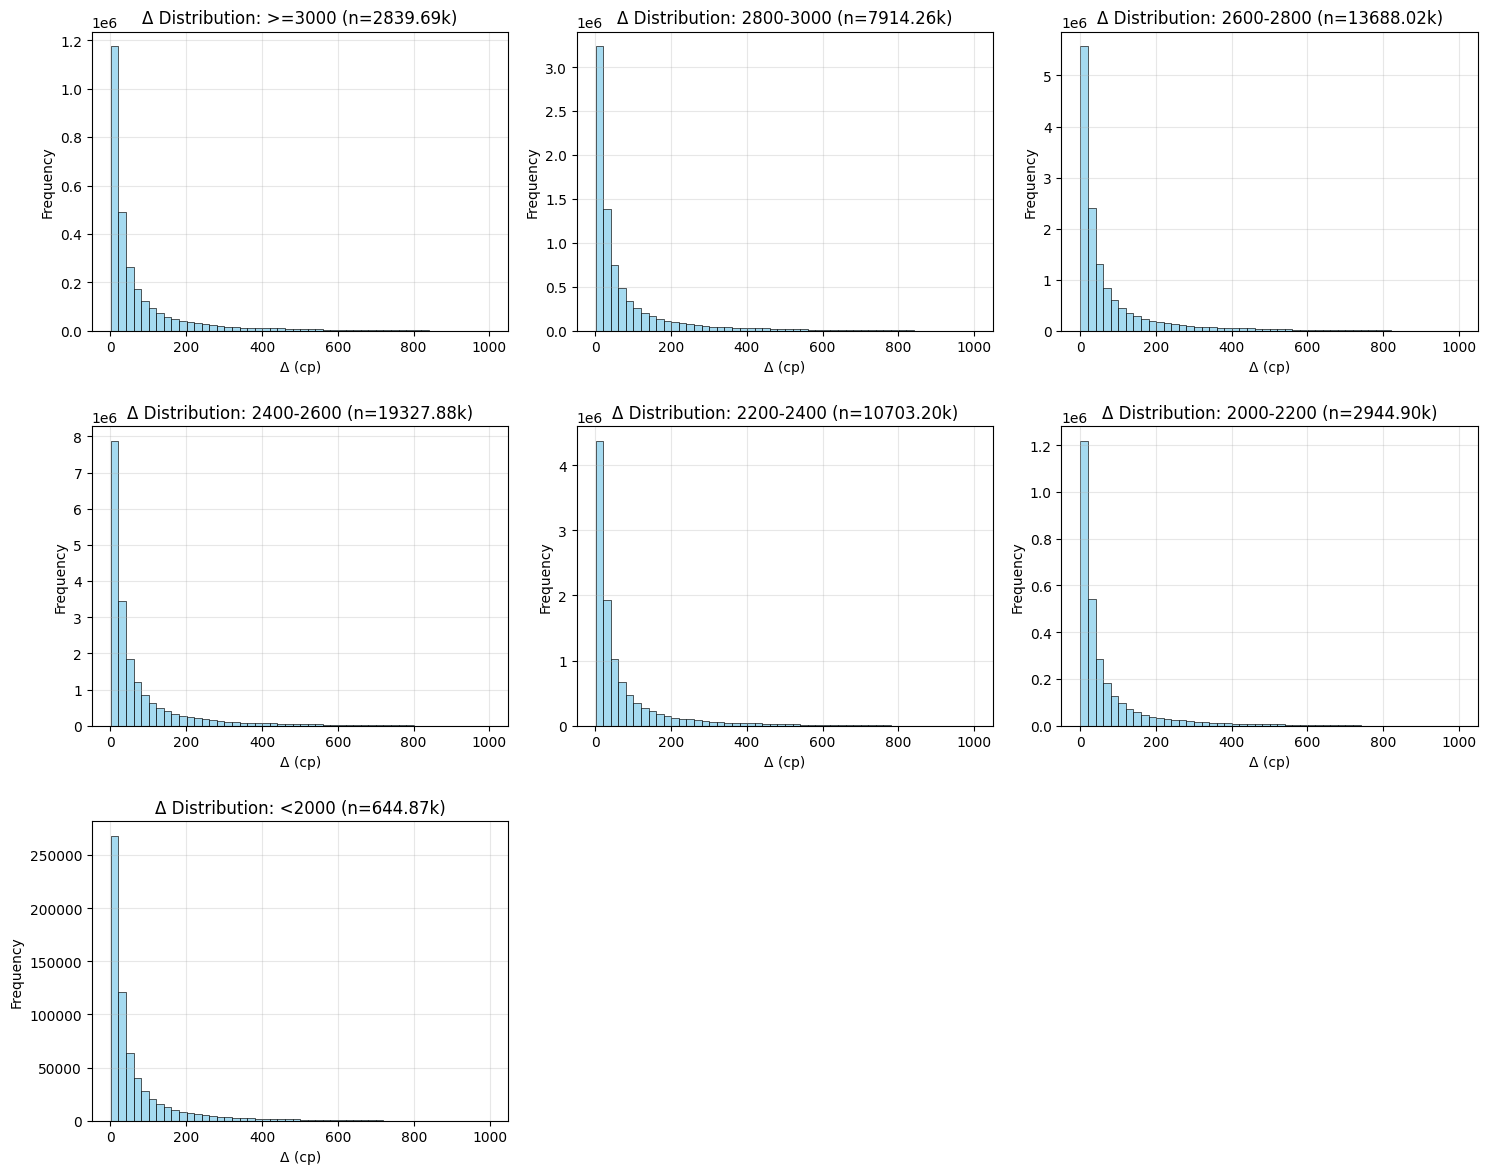

In [25]:
group_order = ['>=3000', '2800-3000', '2600-2800','2400-2600', '2200-2400', '2000-2200', '<2000']
def plot_delta_distribution(df, group_order, x_limit=1000):
    # 创建一个多子图画板，3行3列足够放7个组
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten() # 展平方便循环
    
    for i, g in enumerate(group_order):
        # 1. 筛选该组的有效非强制步
        sub_df = df[(df['ELO_Group'] == g) & (df['Is_Forced'] == 0) & (df['Δ'] > 0)]
        
        # 2. 截取主体部分查看分布
        data_to_plot = sub_df['Δ'][sub_df['Δ'] <= x_limit]
        
        # 3. 画直方图
        ax = axes[i]
        sns.histplot(data_to_plot, bins=50, color='skyblue', ax=ax, kde=False)
        ax.set_title(f'Δ Distribution: {g} (n={len(data_to_plot)/1000:.2f}k)')
        ax.set_xlabel('Δ (cp)')
        ax.set_ylabel('Frequency')
        ax.grid(alpha=0.3)
        
    # 隐藏多余的空白子图
    for j in range(len(group_order), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# 运行查看分布
plot_delta_distribution(df_moves, group_order)

In [ ]:
# 新的方法拟合
def theoretical_logistic(delta, A, tau):
    exponent = np.clip(-delta/tau, -700, 700)
    return A/(1+ np.exp(exponent))

def empirical_curve(df, group_name, delta_min = 30, delta_max = 600, min_count = 100):
    group_df = df[(df['ELO_Group'] == group_name) & (df['Is_Forced'] == 0)]
    group_df = group_df[(group_df['Δ'] > delta_min) & (group_df['Δ'] <= delta_max)]
    if group_df.empty: return None

    counts = group_df.groupby('Δ')['Is_Optimal'].count()
    valid_deltas = counts[counts >= min_count].index
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty: return None
    prob_df=(group_df.groupby('Δ')['Is_Optimal'].mean().reset_index().rename(columns = {'Is_Optimal': 'P_Optimal'}).sort_values('Δ').reset_index(drop=True))
    return prob_df

def fit_mse(prob_df):
    if prob_df is None or prob_df.empty:
        return None, None
    x_data = prob_df['Δ'].values
    y_data = prob_df['P_Optimal'].values
    initial_guess = [y_data.max(), 100.0]
    bounds = ([0.0, 1.0], [1.0, 2000.0])
    try:
        popt, _ = curve_fit(
            theoretical_logistic, 
            x_data, y_data, 
            p0=initial_guess, 
            bounds=bounds
        )
        return popt[0], popt[1]  # 返回最优的 A 和 tau
    except Exception as e:
        print(f"拟合失败: {e}")
        return None, None
group_order = ['>=3000', '2800-3000', '2600-2800',
            '2400-2600', '2200-2400', '2000-2200', '<2000']

all_prob_curves = {}
results = {}


===== 当前正在调试 ELO group: <2000 =====
使用参数 -> delta_max: 600, min_count: 20
拟合成功！最优天花板 A = 0.795, 最优阈值 τ = 198.9


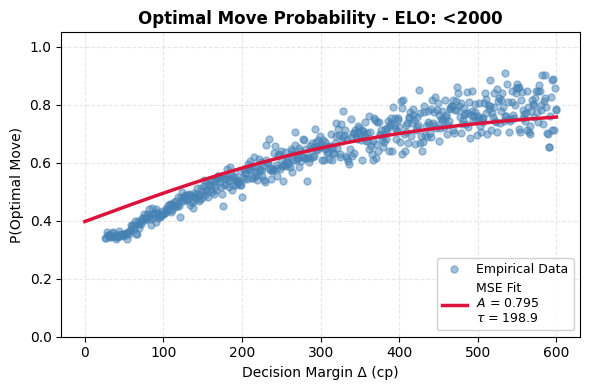

In [133]:
g = '<2000'
d_max = 600
m_cnt = 20

print(f'\n===== 当前正在调试 ELO group: {g} =====')
print(f'使用参数 -> delta_max: {d_max}, min_count: {m_cnt}')

prob_df = empirical_curve(
    df_moves[df_moves['Is_Forced'] == 0], 
    group_name=g, 
    delta_min=25, 
    delta_max=d_max, 
    min_count=m_cnt
)

if prob_df is None or prob_df.empty:
    print('⚠️ 当前参数下没有有效数据，请尝试放宽 delta_max 或 min_count。')
else:
    A, tau = fit_mse(prob_df)
    
    if A is None:
        print('⚠️ 拟合失败，请检查数据分布。')
    else:
        print(f'拟合成功！最优天花板 A = {A:.3f}, 最优阈值 τ = {tau:.1f}')
        plt.figure(figsize=(6, 4))
        
        x_data = prob_df['Δ'].values
        y_data = prob_df['P_Optimal'].values
        
        # 散点
        plt.plot(x_data, y_data, 'o', color='steelblue', alpha=0.5, markersize=5, label='Empirical Data')
        
        # 曲线
        x_smooth = np.linspace(0, x_data.max(), 200) 
        y_smooth = theoretical_logistic(x_smooth, A, tau)
        
        fit_label = f'MSE Fit\n$A$ = {A:.3f}\n$\\tau$ = {tau:.1f}'
        plt.plot(x_smooth, y_smooth, '-', color='crimson', lw=2.5, label=fit_label)

        # 排版
        plt.title(f'Optimal Move Probability - ELO: {g}', fontsize=12, fontweight='bold')
        plt.xlabel('Decision Margin Δ (cp)', fontsize=10)
        plt.ylabel('P(Optimal Move)', fontsize=10)
        plt.ylim(0, 1.05)
        
        plt.legend(loc='lower right', fontsize=9, framealpha=0.9)
        plt.grid(alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()


===== ELO group: >=3000 =====
使用参数 -> delta_max: 600, min_count: 100
最优天花板 A   = 0.889
最优阈值 τ     = 166.3


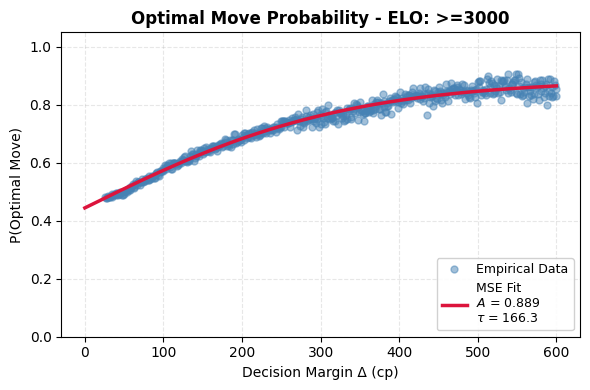


===== ELO group: 2800-3000 =====
使用参数 -> delta_max: 600, min_count: 100
最优天花板 A   = 0.887
最优阈值 τ     = 186.4


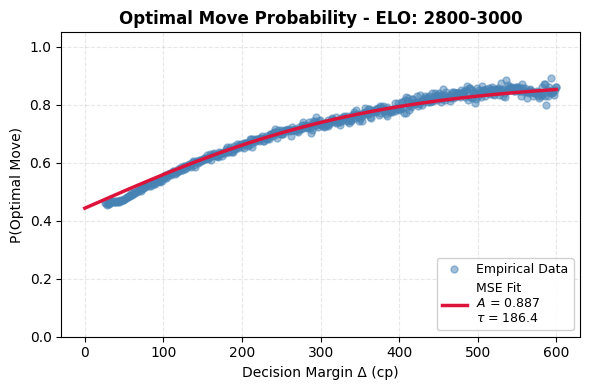


===== ELO group: 2600-2800 =====
使用参数 -> delta_max: 600, min_count: 100
最优天花板 A   = 0.870
最优阈值 τ     = 191.5


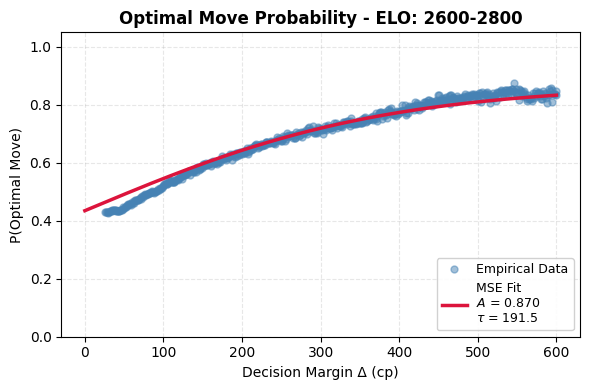


===== ELO group: 2400-2600 =====
使用参数 -> delta_max: 600, min_count: 100
最优天花板 A   = 0.853
最优阈值 τ     = 196.0


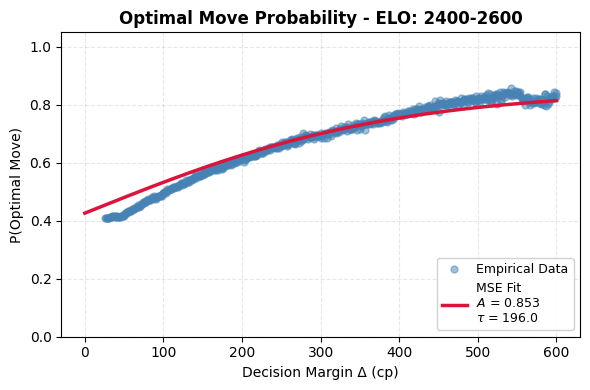


===== ELO group: 2200-2400 =====
使用参数 -> delta_max: 600, min_count: 100
最优天花板 A   = 0.835
最优阈值 τ     = 199.2


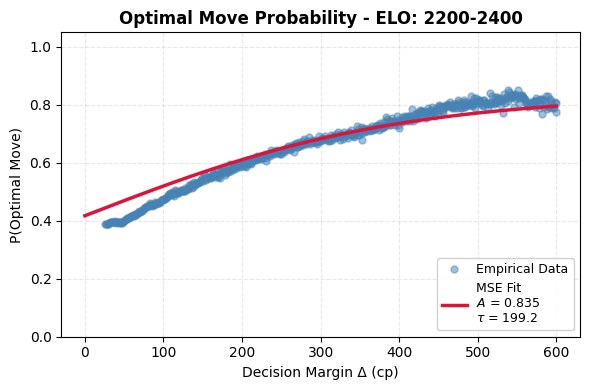


===== ELO group: 2000-2200 =====
使用参数 -> delta_max: 600, min_count: 100
最优天花板 A   = 0.818
最优阈值 τ     = 200.5


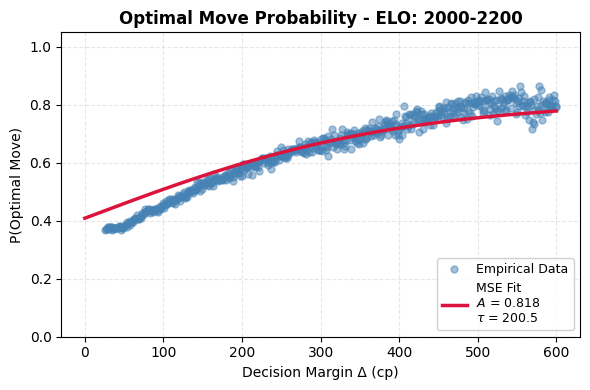


===== ELO group: <2000 =====
使用参数 -> delta_max: 600, min_count: 100
最优天花板 A   = 0.713
最优阈值 τ     = 149.4


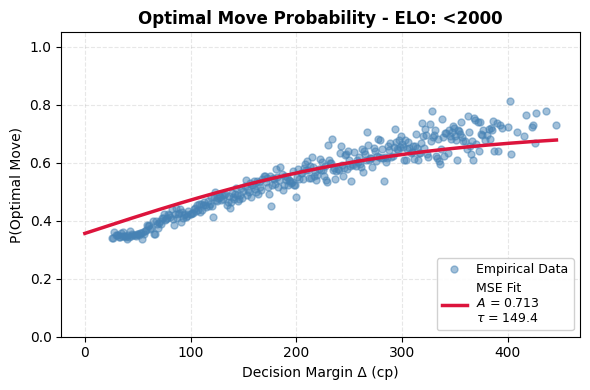

In [136]:
# 定制每个组的参数
group_configs = {
    '>=3000':   {'delta_max': 600,  'min_count': 100},  # 顶尖棋手样本少，阈值放宽点
    '2800-3000':{'delta_max': 600, 'min_count': 100},
    '2600-2800':{'delta_max': 600, 'min_count': 100},
    '2400-2600':{'delta_max': 600, 'min_count': 100}, # 中间段位人多，可以严格点
    '2200-2400':{'delta_max': 600, 'min_count': 100},
    '2000-2200':{'delta_max': 600, 'min_count': 100},
    '<2000':    {'delta_max': 600, 'min_count': 100}  # 低分段样本可能也少
}

all_prob_curves = {}
results = {}
group_order = ['>=3000', '2800-3000', '2600-2800','2400-2600', '2200-2400', '2000-2200', '<2000']

for g in group_order:
    print(f'\n===== ELO group: {g} =====')

    # 从你的配置字典里读取专属参数
    cfg = group_configs.get(g, {'delta_max': 1000, 'min_count': 100})
    d_max = cfg['delta_max']
    m_cnt = cfg['min_count']
    
    print(f'使用参数 -> delta_max: {d_max}, min_count: {m_cnt}')

    # 获取聚合后的经验散点数据
    prob_df = empirical_curve(df_moves[df_moves['Is_Forced'] == 0], group_name=g, delta_min=25, delta_max=d_max, min_count=m_cnt)

    if prob_df is None:
        print('No valid data.')
        continue

    # 执行严谨的 MSE 拟合
    A, tau = fit_mse(prob_df)
    
    if A is None:
        continue

    print(f'最优天花板 A   = {A:.3f}')
    print(f'最优阈值 τ     = {tau:.1f}')

    all_prob_curves[g] = prob_df
    results[g] = {'A': A, 'tau': tau}
    
    # ==========================================
    # 画图：散点和曲线异色显示
    # ==========================================
    plt.figure(figsize=(6, 4))
    
    x_data = prob_df['Δ'].values
    y_data = prob_df['P_Optimal'].values
    
    # 1. 散点：使用半透明的钢蓝色 (steelblue)
    plt.plot(x_data, y_data, 'o', color='steelblue', alpha=0.5, markersize=5, label='Empirical Data')
    
    # 2. 曲线：使用鲜艳的深红色 (crimson)
    x_smooth = np.linspace(0, x_data.max(), 200) 
    y_smooth = theoretical_logistic(x_smooth, A, tau)
    
    fit_label = f'MSE Fit\n$A$ = {A:.3f}\n$\\tau$ = {tau:.1f}'
    plt.plot(x_smooth, y_smooth, '-', color='crimson', lw=2.5, label=fit_label)

    # 排版美化
    plt.title(f'Optimal Move Probability - ELO: {g}', fontsize=12, fontweight='bold')
    plt.xlabel('Decision Margin Δ (cp)', fontsize=10)
    plt.ylabel('P(Optimal Move)', fontsize=10)
    plt.ylim(0, 1.05)
    
    plt.legend(loc='lower right', fontsize=9, framealpha=0.9)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

加权拟合成功！A = 0.810, tau = 186.9


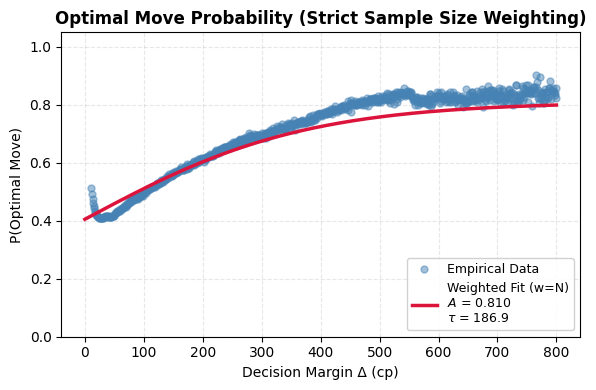

In [152]:
def empirical_curve(df, group_name, delta_min = 10, delta_max = 800, min_count = 100):
    group_df = df[(df['ELO_Group'] == group_name) & (df['Is_Forced'] == 0)]
    group_df = group_df[(group_df['Δ'] > delta_min) & (group_df['Δ'] <= delta_max)]
    if group_df.empty: return None

    # 第一步：计算每个 Δ 的总步数，并过滤掉少于 min_count 的
    counts = group_df.groupby('Δ')['Is_Optimal'].count()
    valid_deltas = counts[counts >= min_count].index
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty: return None
    
    # 【核心修改点】：使用 agg 同时计算 P_Optimal 和 Count
    prob_df = group_df.groupby('Δ')['Is_Optimal'].agg(
        P_Optimal='mean',
        Count='count'
    ).reset_index().sort_values('Δ').reset_index(drop=True)
    
    return prob_df
prob_df = empirical_curve(df_moves, '2400-2600', delta_min = 10, delta_max = 800, min_count = 100)

# 1. 定义你的原版公式
def theoretical_logistic(x, A, tau):
    # 防止溢出
    x_safe = np.clip(-x / tau, -500, 500)
    return A / (1 + np.exp(x_safe))

# 假设重新运行后你已经拿到了带 Count 的 prob_df
x_data = prob_df['Δ'].values
y_data = prob_df['P_Optimal'].values
n_counts = prob_df['Count'].values 

# 2. 【核心】：按照 GPT 的严格统计学推导，样本量 n 越大，权重越高
# curve_fit 的 sigma 代表误差，误差越小权重越高。所以 sigma = 1 / sqrt(n)
sigma_weights = 1.0 / np.sqrt(n_counts)

# 3. 进行加权拟合
p0 = [0.8, 200]
bounds = ([0.0, 1.0], [1.0, 1000.0])

try:
    popt, _ = curve_fit(
        theoretical_logistic, 
        x_data, y_data, 
        p0=p0, bounds=bounds,
        sigma=sigma_weights,    # 传入严格的样本量权重
        absolute_sigma=False
    )
    A_wls, tau_wls = popt[0], popt[1]
    print(f'加权拟合成功！A = {A_wls:.3f}, tau = {tau_wls:.1f}')
except Exception as e:
    print(f"拟合失败: {e}")

# 4. 画图看效果
plt.figure(figsize=(6, 4))
plt.plot(x_data, y_data, 'o', color='steelblue', alpha=0.5, markersize=5, label='Empirical Data')

x_smooth = np.linspace(0, x_data.max(), 200) 
y_smooth = theoretical_logistic(x_smooth, A_wls, tau_wls)

fit_label = f'Weighted Fit (w=N)\n$A$ = {A_wls:.3f}\n$\\tau$ = {tau_wls:.1f}'
plt.plot(x_smooth, y_smooth, '-', color='crimson', lw=2.5, label=fit_label)

plt.title('Optimal Move Probability (Strict Sample Size Weighting)', fontsize=12, fontweight='bold')
plt.xlabel('Decision Margin Δ (cp)', fontsize=10)
plt.ylabel('P(Optimal Move)', fontsize=10)
plt.ylim(0, 1.05)
plt.legend(loc='lower right', fontsize=9, framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

拟合效果好,引入新参数的新公式

Processing ELO: >=3000 ...


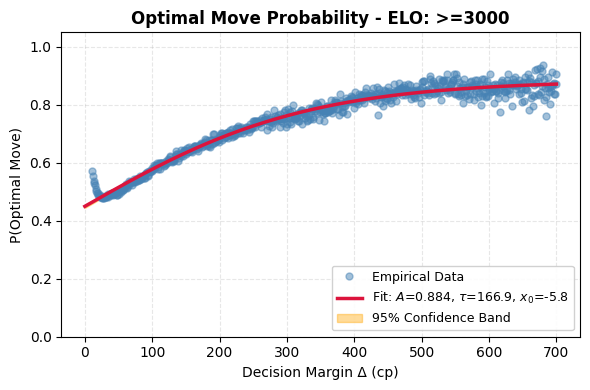


--- ELO >=3000 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.476     |      ± 0.0048
  50    |     0.515     |      ± 0.0040
  100   |     0.578     |      ± 0.0028
  200   |     0.685     |      ± 0.0025
  400   |     0.813     |      ± 0.0020
  600   |     0.861     |      ± 0.0027
--------------------------------------------------
Processing ELO: 2800-3000 ...


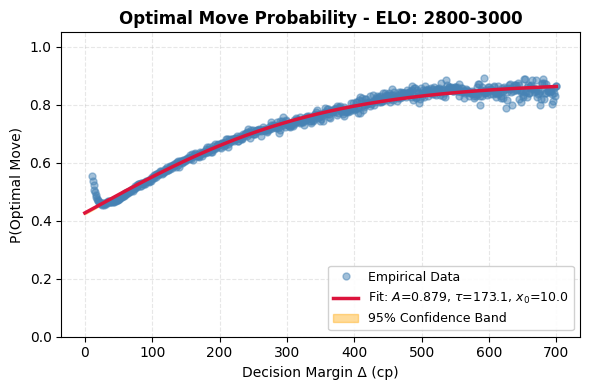


--- ELO 2800-3000 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.452     |      ± 0.0037
  50    |     0.490     |      ± 0.0030
  100   |     0.551     |      ± 0.0022
  200   |     0.659     |      ± 0.0019
  400   |     0.796     |      ± 0.0016
  600   |     0.851     |      ± 0.0021
--------------------------------------------------
Processing ELO: 2600-2800 ...


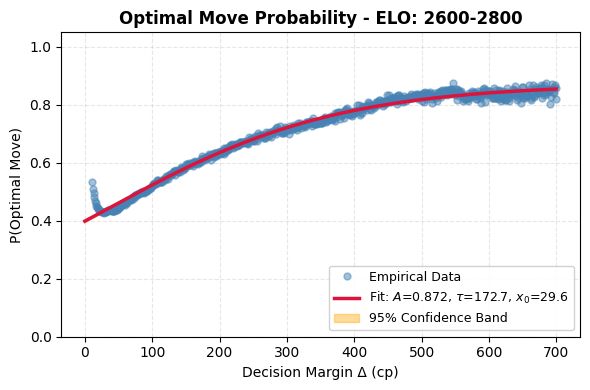


--- ELO 2600-2800 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.424     |      ± 0.0032
  50    |     0.462     |      ± 0.0026
  100   |     0.524     |      ± 0.0019
  200   |     0.635     |      ± 0.0017
  400   |     0.781     |      ± 0.0014
  600   |     0.841     |      ± 0.0019
--------------------------------------------------
Processing ELO: 2400-2600 ...


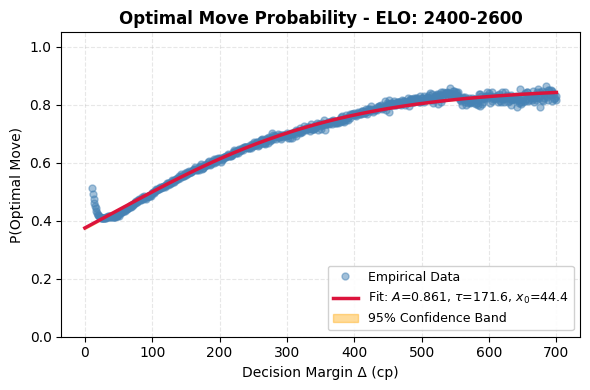


--- ELO 2400-2600 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.400     |      ± 0.0031
  50    |     0.438     |      ± 0.0026
  100   |     0.500     |      ± 0.0020
  200   |     0.613     |      ± 0.0017
  400   |     0.765     |      ± 0.0015
  600   |     0.829     |      ± 0.0018
--------------------------------------------------
Processing ELO: 2200-2400 ...


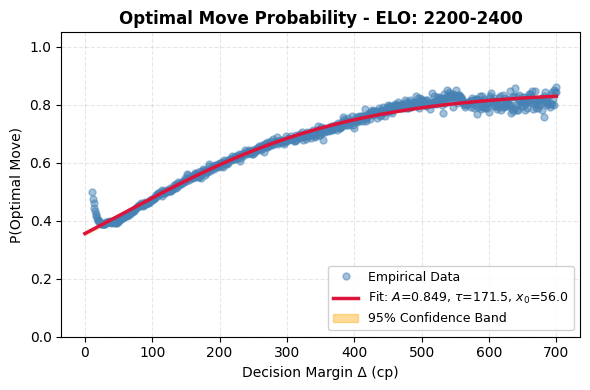


--- ELO 2200-2400 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.380     |      ± 0.0038
  50    |     0.417     |      ± 0.0032
  100   |     0.479     |      ± 0.0025
  200   |     0.593     |      ± 0.0020
  400   |     0.748     |      ± 0.0018
  600   |     0.815     |      ± 0.0023
--------------------------------------------------
Processing ELO: 2000-2200 ...


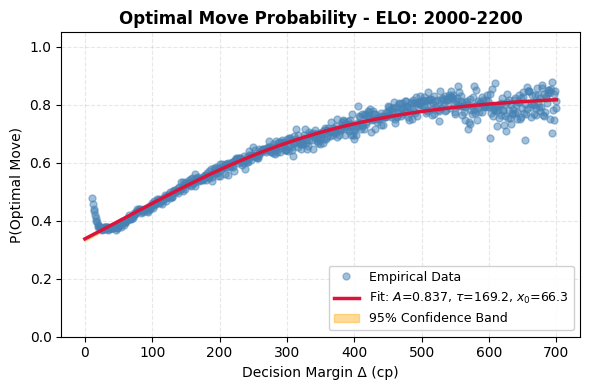


--- ELO 2000-2200 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.362     |      ± 0.0059
  50    |     0.398     |      ± 0.0050
  100   |     0.460     |      ± 0.0038
  200   |     0.576     |      ± 0.0030
  400   |     0.735     |      ± 0.0025
  600   |     0.803     |      ± 0.0034
--------------------------------------------------
Processing ELO: <2000 ...


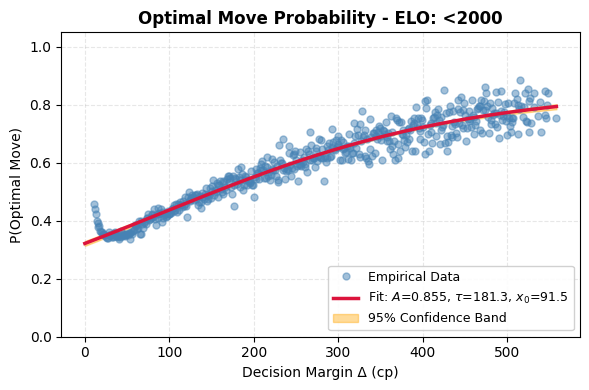


--- ELO <2000 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.344     |      ± 0.0077
  50    |     0.379     |      ± 0.0065
  100   |     0.437     |      ± 0.0049
  200   |     0.552     |      ± 0.0048
  400   |     0.723     |      ± 0.0039
  600   |     0.806     |      ± 0.0105
--------------------------------------------------

Summary of Fitting Parameters:
ELO_Group     A   tau   x0  A_err  tau_err  x0_err  Max_CI_Width  d_max  min_cnt
   >=3000 0.884 166.9 -5.8 0.0024     2.94    1.91        0.0109    700       50
2800-3000 0.879 173.1 10.0 0.0020     2.24    1.34        0.0085    700       50
2600-2800 0.872 172.7 29.6 0.0018     1.91    1.10        0.0069    700       80
2400-2600 0.861 171.6 44.4 0.0019     1.86    1.07        0.0069    700      100
2200-2400 0.849 171.5 56.0 0.0023     2.21    1.28        0.0085    700      100
2000-2200 0.837 169.2 66.3 0.0034     3.17    1.88  

In [158]:
# 新的拟合函数
def theoretical_logistic_shifted(x, A, tau, x0):
    x_safe = np.clip(-(x - x0) / tau, -500, 500)
    return A / (1 + np.exp(x_safe))

def fit_mse_shifted(prob_df):
    x_data = prob_df['Δ'].values
    y_data = prob_df['P_Optimal'].values
    
    p0 = [0.85, 200, 50] 
    bounds = ([0.0, 1.0, -500.0], [1.0, 1000.0, 500.0])
    
    try:
        popt, pcov = curve_fit(theoretical_logistic_shifted, x_data, y_data, p0=p0, bounds=bounds)
        # popt [A, TAU, X0]
        # pcov 协方差矩阵
        return popt, pcov
    except Exception as e:
        print(f"Fit failed: {e}")
        return None, None

# 配置遍历参数，人为可调节
group_order = ['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000']
group_configs = {
    '>=3000':   {'delta_max': 700,  'min_count': 50},  
    '2800-3000':{'delta_max': 700,  'min_count': 50},
    '2600-2800':{'delta_max': 700,  'min_count': 80},
    '2400-2600':{'delta_max': 700,  'min_count': 100}, 
    '2200-2400':{'delta_max': 700,  'min_count': 100},
    '2000-2200':{'delta_max': 700,  'min_count': 50},
    '<2000':    {'delta_max': 700,  'min_count': 50}  
}

summary_results = []

# 画图
for g in group_order:
    print(f'Processing ELO: {g} ...')
    
    cfg = group_configs.get(g, {'delta_max': 800, 'min_count': 50})
    d_max = cfg['delta_max']
    m_cnt = cfg['min_count']
    
    prob_df = empirical_curve(df_moves[df_moves['Is_Forced'] == 0], group_name=g, 
        delta_min=10, delta_max=d_max, min_count=m_cnt)
    # 数据不足的组跳过
    if prob_df is None or prob_df.empty:
        print(f"Insufficient data for group {g}, skipping.")
        continue

    popt, pcov = fit_mse_shifted(prob_df)
    
    if popt is not None:
        A, tau, x0 = popt
        perr = np.sqrt(np.diag(pcov))  #协方差矩阵对角线开根号为标准差
        
        x_data = prob_df['Δ'].values
        y_data = prob_df['P_Optimal'].values
        x_smooth = np.linspace(0, x_data.max(), 200) 
        y_smooth = theoretical_logistic_shifted(x_smooth, A, tau, x0)

        # 阴影生成逻辑
        sample_params = np.random.multivariate_normal(popt, pcov, 1000)
        valid_params = []
        # 过滤无效参数
        for params in sample_params:
            A_s, tau_s, x0_s = params
            if 0 < A_s < 1 and tau_s > 0:
                valid_params.append(params)

        valid_params = np.array(valid_params)
        y_samples = np.array([theoretical_logistic_shifted(x_smooth, *params) for params in valid_params])

        y_lower = np.percentile(y_samples, 2.5, axis=0)
        y_upper = np.percentile(y_samples, 97.5, axis=0)
        
        max_band_width = np.max(y_upper - y_lower)
        
        # 记录汇总数据
        summary_results.append({
            'ELO_Group': g,
            'A': round(A, 3),
            'tau': round(tau, 1),
            'x0': round(x0, 1),
            'A_err': round(perr[0], 4),
            'tau_err': round(perr[1], 2),
            'x0_err': round(perr[2], 2),
            'Max_CI_Width': round(max_band_width, 4),
            'd_max': d_max,
            'min_cnt': m_cnt
        })
        
        # 绘图
        plt.figure(figsize=(6, 4))
        plt.plot(x_data, y_data, 'o', color='steelblue', alpha=0.5, markersize=5, label='Empirical Data')
        fit_label = f'Fit: $A$={A:.3f}, $\\tau$={tau:.1f}, $x_0$={x0:.1f}'
        plt.plot(x_smooth, y_smooth, '-', color='crimson', lw=2.5, label=fit_label)
        plt.fill_between(x_smooth, y_lower, y_upper, color='orange', alpha=0.4, label='95% Confidence Band')
        plt.title(f'Optimal Move Probability - ELO: {g}', fontsize=12, fontweight='bold')
        plt.xlabel('Decision Margin Δ (cp)', fontsize=10)
        plt.ylabel('P(Optimal Move)', fontsize=10)
        plt.ylim(0, 1.05)
        plt.legend(loc='lower right', fontsize=9, framealpha=0.9)
        plt.grid(alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()

        # 打印不同横坐标时候的不确定误差       
        # 想要观察的横坐标
        target_deltas = np.array([20, 50, 100, 200, 400, 600])
        # 这几个点的理论预测中心值
        y_targets_center = theoretical_logistic_shifted(target_deltas, A, tau, x0)
        # 这几个点的 1000 个可能的 Y 值
        y_targets_samples = np.array([theoretical_logistic_shifted(target_deltas, *params) for params in valid_params])
        # 提取 95% 置信区间的上下界
        y_targets_lower = np.percentile(y_targets_samples, 2.5, axis=0)
        y_targets_upper = np.percentile(y_targets_samples, 97.5, axis=0)
        # 上下浮动的幅度 (即 ± 的那个数字)
        fluctuations = (y_targets_upper - y_targets_lower) / 2
        print(f"\n--- ELO {g} 关键节点的预测波动 (95% CI) ---")
        print(" Delta  |  Predicted P  |  95% CI Fluctuation (±)")
        print("--------|---------------|-------------------------")
        for i in range(len(target_deltas)):
            d = target_deltas[i]
            p_val = y_targets_center[i]
            fluc = fluctuations[i]
            print(f"  {d:<4}  |     {p_val:.3f}     |      ± {fluc:.4f}")
        print("-" * 50)

# 打印最终参数汇总表
print('\nSummary of Fitting Parameters:')
summary_df = pd.DataFrame(summary_results)
print(summary_df.to_string(index=False))

In [185]:
clock_info = pd.read_csv(r'..\..\data\input\clock_info.csv')
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())

white_sec
<class 'str'>    1017708
Name: count, dtype: int64
black_sec
<class 'str'>    1017708
Name: count, dtype: int64


In [186]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [187]:
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [x]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [v]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

clock_info['white_sec'] = clock_info['white_sec'].progress_apply(ensure_list)
clock_info['black_sec'] = clock_info['black_sec'].progress_apply(ensure_list)
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())
clock_info['second_list'] = clock_info['second_list'].progress_apply(ensure_list)
print(clock_info['second_list'].apply(type).value_counts())

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

white_sec
<class 'list'>    1017708
Name: count, dtype: int64
black_sec
<class 'list'>    1017708
Name: count, dtype: int64


  0%|          | 0/1017708 [00:00<?, ?it/s]

second_list
<class 'list'>    1017708
Name: count, dtype: int64


In [188]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [164]:
# 大数据集 合并时间 test1
clock_dict = dict(zip(clock_info['uid'], clock_info['second_list']))

# 2. 优化你的处理函数 (放弃缓慢的 apply，用更轻量的列表推导)
def process_chunk(chunk):
    # 将需要的列抽成 NumPy 数组或列表，遍历速度会起飞
    uids = chunk['uid'].values
    move_idxs = chunk['Move_Idx'].values - 1  # 提前全局减 1
    
    remain_times = []
    # zip 是在底层 C 语言级别打包，速度极快
    for uid, idx in zip(uids, move_idxs):
        # 查字典逻辑
        if uid in clock_dict and idx < len(clock_dict[uid]):
            remain_times.append(clock_dict[uid][idx])
        else:
            remain_times.append(np.nan) # 缺失值用 NaN，Parquet 完美支持
            
    chunk['Remain_Time'] = pd.Series(remain_times, index=chunk.index, dtype='float32').round(2)
    return chunk

# 3. 分批写入单一 Parquet 文件的核心逻辑
chunk_size = 1000000  # 每次吃进 100 万行，你可以根据你电脑剩余内存调大或调小
parquet_file = 'df_moves2.parquet'
writer = None  # 初始化写入器

print("开始分批高速处理并写入 Parquet...")

# 计算总行数用于显示进度
total_rows = len(df_moves)

for i in range(0, total_rows, chunk_size):
    print(f"正在处理批次: {i} 到 {min(i + chunk_size, total_rows)} ...")
    
    # 切片获取当前批次 (使用 .copy() 避免 Pandas 的 SettingWithCopyWarning)
    chunk = df_moves.iloc[i:i + chunk_size].copy()
    
    # 高速运算
    chunk = process_chunk(chunk)
    
    # 将 Pandas DataFrame 转换为 PyArrow Table (带有严格 Schema 的数据结构)
    table = pa.Table.from_pandas(chunk)
    
    # 如果是第一批数据，我们需要利用它的 Schema 来初始化 ParquetWriter
    if writer is None:
        writer = pq.ParquetWriter(parquet_file, table.schema)
    
    # 追加写入当前批次的数据 (Row Group)
    writer.write_table(table)
    
    # 主动删除 chunk 释放当前循环的内存 (虽然 Python 会自动回收，但显式删除更稳)
    del chunk
    del table

# 4. 极度重要：循环结束后必须关闭 writer！
# 这一步会把 Parquet 的元数据 (Footer) 写进去，否则文件会损坏无法读取
if writer:
    writer.close()

print(f"所有数据已安全保留格式并压缩至: {parquet_file}")

开始分批高速处理并写入 Parquet...
正在处理批次: 0 到 1000000 ...
正在处理批次: 1000000 到 2000000 ...
正在处理批次: 2000000 到 3000000 ...
正在处理批次: 3000000 到 4000000 ...
正在处理批次: 4000000 到 5000000 ...
正在处理批次: 5000000 到 6000000 ...
正在处理批次: 6000000 到 7000000 ...
正在处理批次: 7000000 到 8000000 ...
正在处理批次: 8000000 到 9000000 ...
正在处理批次: 9000000 到 10000000 ...
正在处理批次: 10000000 到 11000000 ...
正在处理批次: 11000000 到 12000000 ...
正在处理批次: 12000000 到 13000000 ...
正在处理批次: 13000000 到 14000000 ...
正在处理批次: 14000000 到 15000000 ...
正在处理批次: 15000000 到 16000000 ...
正在处理批次: 16000000 到 17000000 ...
正在处理批次: 17000000 到 18000000 ...
正在处理批次: 18000000 到 19000000 ...
正在处理批次: 19000000 到 20000000 ...
正在处理批次: 20000000 到 21000000 ...
正在处理批次: 21000000 到 22000000 ...
正在处理批次: 22000000 到 23000000 ...
正在处理批次: 23000000 到 24000000 ...
正在处理批次: 24000000 到 25000000 ...
正在处理批次: 25000000 到 26000000 ...
正在处理批次: 26000000 到 27000000 ...
正在处理批次: 27000000 到 28000000 ...
正在处理批次: 28000000 到 29000000 ...
正在处理批次: 29000000 到 30000000 ...
正在处理批次: 30000000 到 31000000 ...
正在处理批次: 31

In [ ]:
# 小数据集版本的合并时间，别跑
# clock_info合并至df_moves
clock_dict = dict(zip(clock_info['uid'], clock_info['second_list']))
def get_remaining_time(row):
    uid = row['uid']
    move_idx = row['Move_Idx']-1   # Move_Idx比对应的列表里元素index大1
    if uid in clock_dict:
        time_list = clock_dict[uid]
        if move_idx < len(time_list):
            return time_list[move_idx]
    return None
df_moves['Remain_Time'] = df_moves.progress_apply(get_remaining_time, axis=1)

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [166]:
df_moves = pd.read_parquet('df_moves2.parquet')
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time
0,34,1,Dennis Wagner,White,33.0,36.0,34,31,25,16,-,0,0,3.0,6.0,2802.0,2800-3000,0,1,179.800003
1,34,2,Petar Ratkovic,Black,36.0,33.0,34,34,42,48,-,0,0,3.0,4.0,2463.0,2400-2600,0,1,177.800003
2,34,3,Dennis Wagner,White,30.0,36.0,33,27,25,20,-,0,0,6.0,7.0,2802.0,2800-3000,0,1,178.500000
3,34,4,Petar Ratkovic,Black,44.0,30.0,63,66,78,79,-,0,0,14.0,38.0,2463.0,2400-2600,0,0,178.699997
4,34,5,Dennis Wagner,White,32.0,44.0,35,26,21,21,-,0,0,12.0,15.0,2802.0,2800-3000,0,0,179.199997


In [168]:
# 根据剩余时间去分组
def time_group(second):
    if second <= 15:
        return 'Extremely Tense (0-15)'
    elif 15< second <= 70:
        return 'Tense (15-70)'
    elif 70< second <=170:
        return 'Middle (70-170)'
    else:
        return 'Rich (>170)'

df_moves['Time_Group'] = df_moves['Remain_Time'].apply(time_group)
df_moves['Time_Group'].value_counts(normalize=True)

Time_Group
Middle (70-170)           0.376518
Tense (15-70)             0.243820
Extremely Tense (0-15)    0.193239
Rich (>170)               0.186423
Name: proportion, dtype: float64

In [169]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group
0,34,1,Dennis Wagner,White,33.0,36.0,34,31,25,16,...,0,0,3.0,6.0,2802.0,2800-3000,0,1,179.800003,Rich (>170)
1,34,2,Petar Ratkovic,Black,36.0,33.0,34,34,42,48,...,0,0,3.0,4.0,2463.0,2400-2600,0,1,177.800003,Rich (>170)
2,34,3,Dennis Wagner,White,30.0,36.0,33,27,25,20,...,0,0,6.0,7.0,2802.0,2800-3000,0,1,178.500000,Rich (>170)
3,34,4,Petar Ratkovic,Black,44.0,30.0,63,66,78,79,...,0,0,14.0,38.0,2463.0,2400-2600,0,0,178.699997,Rich (>170)
4,34,5,Dennis Wagner,White,32.0,44.0,35,26,21,21,...,0,0,12.0,15.0,2802.0,2800-3000,0,0,179.199997,Rich (>170)


# Re-darw by time group
画这个图的时候把强制走子过滤掉了

正在处理: Time=Rich (>170), ELO=2800-3000, Samples=1616474
正在处理: Time=Rich (>170), ELO=2400-2600, Samples=3850838
正在处理: Time=Rich (>170), ELO=>=3000, Samples=599995
正在处理: Time=Rich (>170), ELO=2600-2800, Samples=2782312
正在处理: Time=Rich (>170), ELO=2200-2400, Samples=2101887
正在处理: Time=Rich (>170), ELO=2000-2200, Samples=564184
正在处理: Time=Rich (>170), ELO=<2000, Samples=123751
正在处理: Time=Middle (70-170), ELO=2800-3000, Samples=3126233
正在处理: Time=Middle (70-170), ELO=2400-2600, Samples=7850502
正在处理: Time=Middle (70-170), ELO=>=3000, Samples=1146155
正在处理: Time=Middle (70-170), ELO=2600-2800, Samples=5494472
正在处理: Time=Middle (70-170), ELO=2200-2400, Samples=4379165
正在处理: Time=Middle (70-170), ELO=2000-2200, Samples=1222200
正在处理: Time=Middle (70-170), ELO=<2000, Samples=289421
正在处理: Time=Tense (15-70), ELO=2800-3000, Samples=2013115
正在处理: Time=Tense (15-70), ELO=2400-2600, Samples=5111063
正在处理: Time=Tense (15-70), ELO=>=3000, Samples=691148
正在处理: Time=Tense (15-70), ELO=2600-2800, Samples=3570

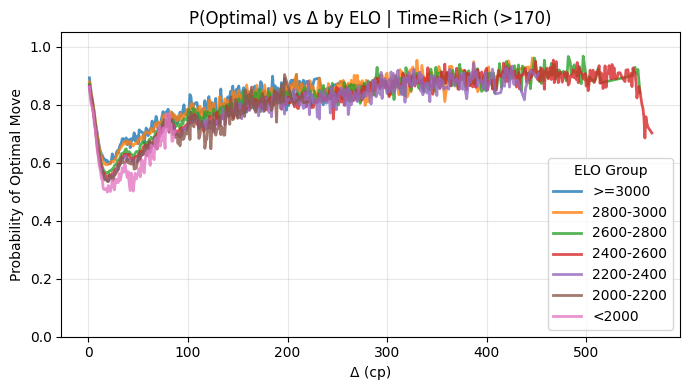

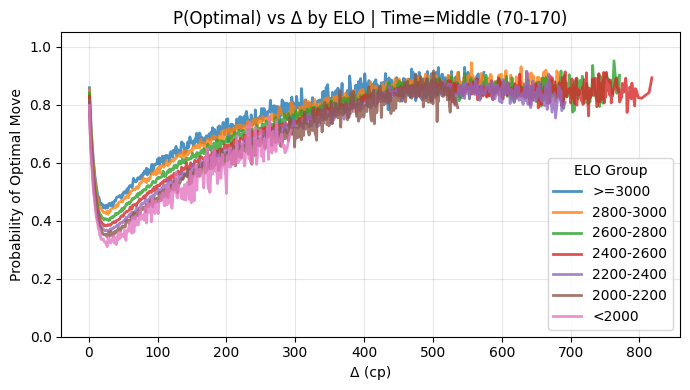

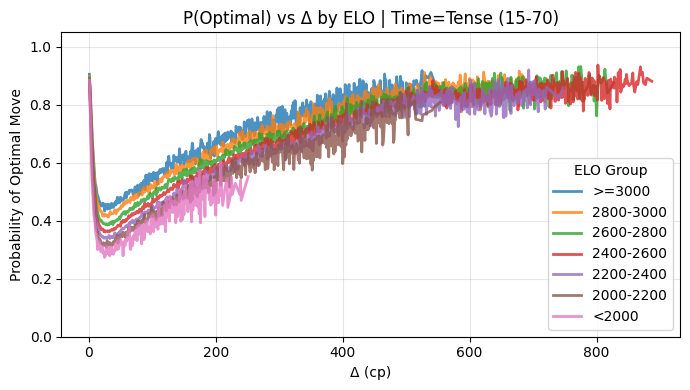

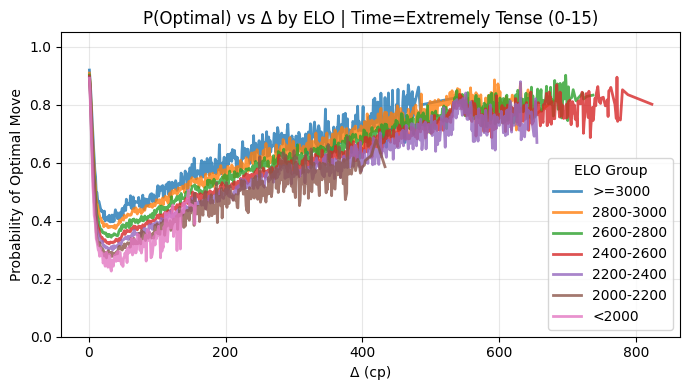

In [171]:
def empirical_curve_v2(df, label, delta_max=1000, show_plot=True):
    # 只过滤非强制着法 和 过滤 Δ 范围
    group_df = df[df['Is_Forced'] == 0].copy()
    group_df = group_df[(group_df['Δ'] > 0) & (group_df['Δ'] <= delta_max)]
    
    if group_df.empty:
        print(f"Warning: No data for {label}")
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    valid_deltas = counts[counts >= 100].index   #50可以调
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty:
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    # 统计概率，prob_df包含每个Δ和对应的最优步概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal': 'P_Optimal'}, inplace=True)
    
    return prob_df

# 按照时间紧张程度看不同elo组的表现情况
all_prob_curves_time = {}
time_groups = df_moves['Time_Group'].unique()
elo_groups = df_moves['ELO_Group'].unique()

for t_group in time_groups:
    all_prob_curves_time[t_group] = {}
    for e_group in elo_groups:
        # 在此处进行精确过滤
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        
        prob_curve = empirical_curve_v2(
            df = sub_df,
            label = f'{e_group} | {t_group}',
            delta_max = 1000,
            show_plot = False # 循环中关闭单图，最后一起画总图
        )
        all_prob_curves_time[t_group][e_group] = prob_curve
# 具体画图
for t_group in time_groups:
    plt.figure(figsize=(7,4))
    elo_order=['>=3000', '2800-3000', '2600-2800',
               '2400-2600', '2200-2400', '2000-2200', '<2000']
    colors = plt.cm.tab10.colors

    for i, e_group in enumerate(elo_order):
        if e_group not in all_prob_curves_time[t_group]:
            continue

        curve = all_prob_curves_time[t_group][e_group]
        if curve is None or curve.empty:
            continue

        plt.plot(
            curve['Δ'],
            curve['P_Optimal'],
            lw=2,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=e_group
        )

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'P(Optimal) vs Δ by ELO | Time={t_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend(title='ELO Group')
    plt.tight_layout()
    plt.show()


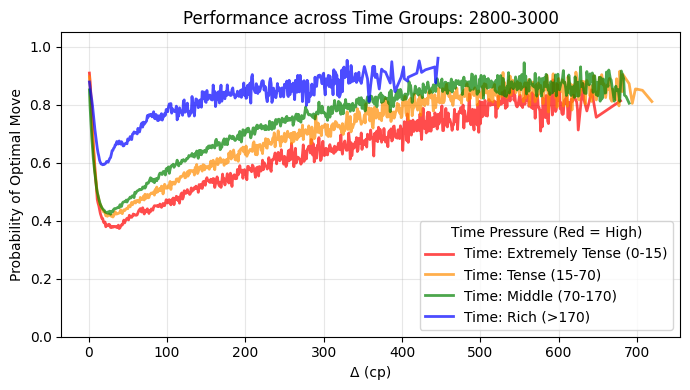

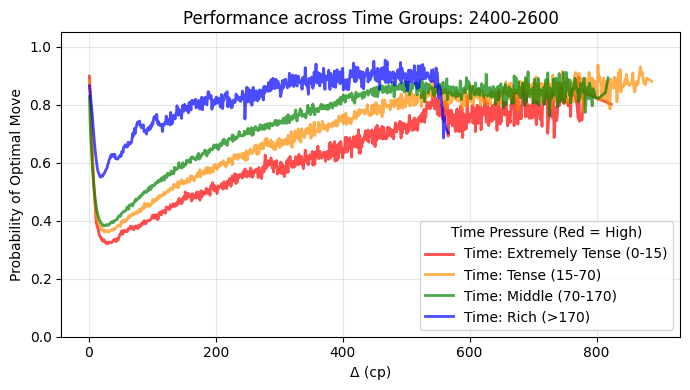

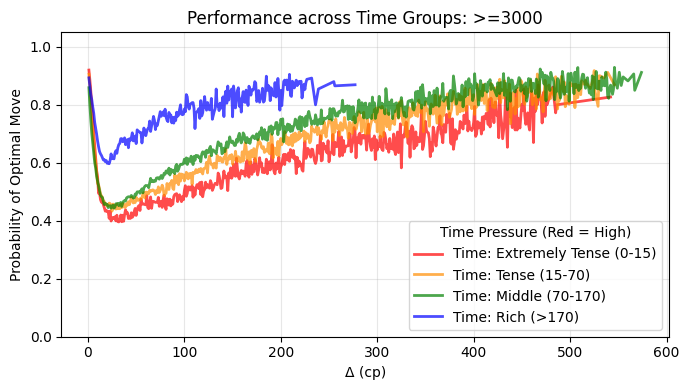

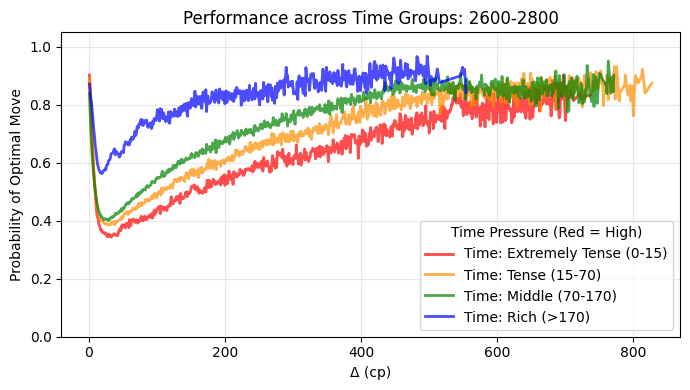

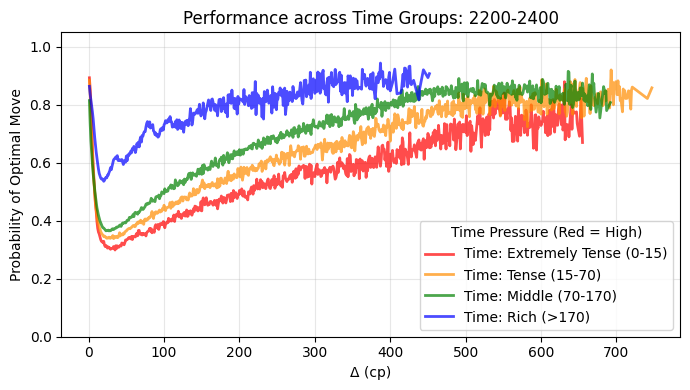

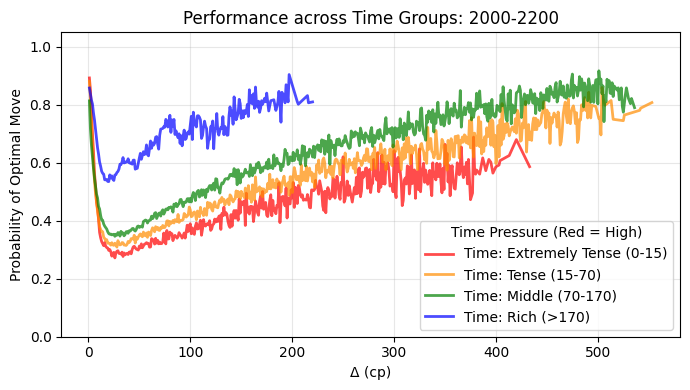

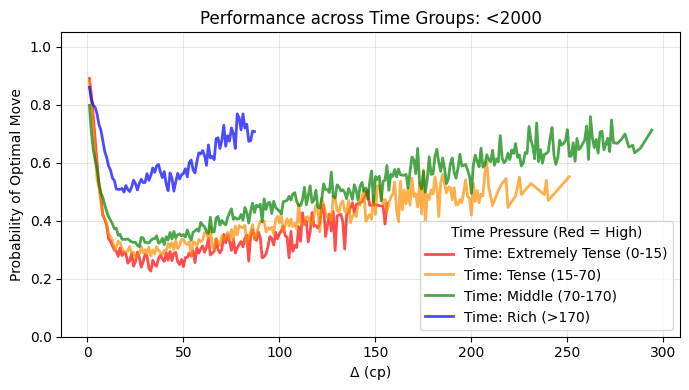

In [172]:
time_color_map = {
    'Extremely Tense (0-15)': 'red',
    'Tense (15-70)': 'darkorange',
    'Middle (70-170)': 'green',
    'Rich (>170)': 'blue'
}

legend_order = [
    'Extremely Tense (0-15)',
    'Tense (15-70)',
    'Middle (70-170)',
    'Rich (>170)'
]

for e_group in elo_groups:
    plt.figure(figsize=(7, 4))

    for t_group in legend_order:
        curve = all_prob_curves_time[t_group].get(e_group)
        if curve is None or curve.empty:
            continue

        plt.plot(
            curve['Δ'],
            curve['P_Optimal'],
            lw=2,
            alpha=0.7,
            color=time_color_map[t_group],
            label=f'Time: {t_group}'
        )

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'Performance across Time Groups: {e_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)

    # —— 手动控制 legend 顺序 ——
    handles, labels = plt.gca().get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    ordered_handles = []
    ordered_labels = []

    for t in legend_order:
        label = f'Time: {t}'
        if label in label_to_handle:
            ordered_handles.append(label_to_handle[label])
            ordered_labels.append(label)

    plt.legend(
        ordered_handles,
        ordered_labels,
        title="Time Pressure (Red = High)"
    )

    plt.tight_layout()
    plt.show()


# Time-Weighted

In [173]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group
0,34,1,Dennis Wagner,White,33.0,36.0,34,31,25,16,...,0,0,3.0,6.0,2802.0,2800-3000,0,1,179.800003,Rich (>170)
1,34,2,Petar Ratkovic,Black,36.0,33.0,34,34,42,48,...,0,0,3.0,4.0,2463.0,2400-2600,0,1,177.800003,Rich (>170)
2,34,3,Dennis Wagner,White,30.0,36.0,33,27,25,20,...,0,0,6.0,7.0,2802.0,2800-3000,0,1,178.500000,Rich (>170)
3,34,4,Petar Ratkovic,Black,44.0,30.0,63,66,78,79,...,0,0,14.0,38.0,2463.0,2400-2600,0,0,178.699997,Rich (>170)
4,34,5,Dennis Wagner,White,32.0,44.0,35,26,21,21,...,0,0,12.0,15.0,2802.0,2800-3000,0,0,179.199997,Rich (>170)


In [174]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [189]:
def safe_literal_eval(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val

clock_info['white_durations'] = clock_info['white_durations'].progress_apply(safe_literal_eval)
clock_info['black_durations'] = clock_info['black_durations'].progress_apply(safe_literal_eval)

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

In [190]:
# 增加每步的实际走子时间 大数据集版本 test1
print("正在构建时间查询字典")
time_lookup = clock_info.set_index('uid')[['white_durations', 'black_durations']].to_dict('index')
def process_chunk_movetime(chunk):
    uids = chunk['uid'].values
    move_idxs = chunk['Move_Idx'].values
    colors = chunk['Color'].values
    move_times = []
    
    # 遍历三个数组
    for uid, move_idx, color in zip(uids, move_idxs, colors):
        val = np.nan  # 默认值为 NaN
        if uid in time_lookup:
            game_times = time_lookup[uid]
            # 颜色判断
            if color == 'White':
                durations = game_times['white_durations']
            elif color == 'Black':
                durations = game_times['black_durations']
            else:
                durations = None
            # 计算索引
            list_index = (move_idx - 1) // 2
            if isinstance(durations, list) and 0 <= list_index < len(durations):
                val = durations[list_index]
        move_times.append(val)
    # 转为 float32  保留 2 位小数
    chunk['Move_Time'] = pd.Series(move_times, index=chunk.index, dtype='float32').round(2)
    return chunk

# 3. 分批处理并写入 Parquet
chunk_size = 10000000  # 每次吃1000 万行
parquet_file = 'df_moves3.parquet'
writer = None

total_rows = len(df_moves)
print(f"开始分批高速处理，总数据量: {total_rows} 行...")

for i in range(0, total_rows, chunk_size):
    end_idx = min(i + chunk_size, total_rows)
    print(f"正在处理并写入: {i} 到 {end_idx} ...")
    
    chunk = df_moves.iloc[i:end_idx].copy()
    chunk = process_chunk_movetime(chunk)
    table = pa.Table.from_pandas(chunk)
    if writer is None:
        # 第一批数据时，根据其 Schema 初始化 Writer
        writer = pq.ParquetWriter(parquet_file, table.schema)
    
    writer.write_table(table)
    del chunk
    del table
    gc.collect()
if writer:
    writer.close()

print(f"包含 Move_Time (2位小数) 的数据已安全持久化至: {parquet_file}")

正在构建时间查询字典
开始分批高速处理，总数据量: 62435670 行...
正在处理并写入: 0 到 10000000 ...
正在处理并写入: 10000000 到 20000000 ...
正在处理并写入: 20000000 到 30000000 ...
正在处理并写入: 30000000 到 40000000 ...
正在处理并写入: 40000000 到 50000000 ...
正在处理并写入: 50000000 到 60000000 ...
正在处理并写入: 60000000 到 62435670 ...
包含 Move_Time (2位小数) 的数据已安全持久化至: df_moves3.parquet


In [ ]:
df_moves = pd.read_parquet('df_moves3.parquet')
df_moves.head()

In [183]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group'],
      dtype='object')

In [179]:
%whos

Variable                       Type              Data/Info
----------------------------------------------------------
A                              float64           0.8546261520232248
A_s                            float64           0.8614838258343271
A_wls                          float64           0.8102251478048913
all_prob_curves                dict              n=7
all_prob_curves_time           dict              n=4
ast                            module            <module 'ast' from 'c:\\U<...>\Python312\\Lib\\ast.py'>
bins                           list              n=8
bounds                         tuple             n=2
calculate_delta                function          <function calculate_delta at 0x000002BC2C7D4FE0>
cfg                            dict              n=2
chunk_iterator                 TextFileReader    <pandas.io.parsers.reader<...>ct at 0x000002BC2B9CB170>
chunk_size                     int               10000000
clock_dict                     dict            

In [180]:
del clock_dict
del clock_info
del elo_info                       
del input_csv
del output_csv                     
del process_chunk                  
del process_chunk_movetime
gc.collect

<function gc.collect(generation=2)>

In [ ]:
# 小数据集版本的 增加每步时间
time_lookup = clock_info.set_index('uid')[['white_durations', 'black_durations']].to_dict('index')
def get_move_duration(row):
    uid = row['uid']
    move_idx = row['Move_Idx']
    color = row['Color']
    
    # 检查该局游戏是否存在于时间表中
    if uid not in time_lookup:
        return None
    
    # 根据颜色选择对应的时间列表
    game_times = time_lookup[uid]
    if color == 'White':
        durations = game_times['white_durations']
    elif color == 'Black':
        durations = game_times['black_durations']
    else:
        return None
        
    # 计算列表索引 (关键数学逻辑)
    # Move_Idx: 1, 2, 3, 4 ...
    # Index:    0, 0, 1, 1 ...
    list_index = (move_idx - 1) // 2
    
    if durations and 0 <= list_index < len(durations):
        return durations[list_index]
    else:
        return None

# 4. 应用到 df_moves
print("正在匹配时间数据...")
df_moves['Move_Time'] = df_moves.progress_apply(get_move_duration, axis=1)

# 5. 检查结果
print(df_moves[['uid', 'Move_Idx', 'Color', 'Move_Time']].head(10))

正在匹配时间数据...


  0%|          | 0/9086334 [00:00<?, ?it/s]

   uid  Move_Idx  Color  Move_Time
0   34         1  White        1.3
1   34         2  Black       -0.9
2   34         3  White       -0.7
3   34         4  Black        0.4
4   34         5  White        0.1
5   34         6  Black        0.0
6   34         7  White       -0.5
7   34         8  Black       -0.2
8   34         9  White        0.2
9   34        10  Black       -0.5


In [182]:
df_moves.to_parquet('0314.parquet')

# 运行到这里停一下，新开一个notebook